In [709]:
# color="#1ca39c" - green
# color="#ffad00" - yellow

In [710]:
import pandas as pd
from  pathlib import Path
import importlib as plt
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

# Datasets
- Client Profiles (df_final_demo): Demographics like age, gender, and account details of our clients.
- Digital Footprints (df_final_web_data): A detailed trace of client interactions online, divided into two parts: pt_1 and pt_2.
- Experiment Roster (df_final_experiment_clients): A list revealing which clients were part of the grand experiment.
- Project Phases & Tasks

| Column               | Description                                             |
| -------------------- | ------------------------------------------------------- |
| **client_id**        | Unique identifier for each client                       |
| **variation**        | Indicates whether the client was part of the experiment |
| **visitor_id**       | Unique ID for each client–device combination            |
| **visit_id**         | Unique identifier for each web visit/session            |
| **process_step**     | Represents each step in the digital process             |
| **date_time**        | Timestamp of each web activity                          |
| **clnt_tenure_yr**   | Client tenure with Vanguard (in years)                  |
| **clnt_tenure_mnth** | Client tenure with Vanguard (in months)                 |
| **clnt_age**         | Age of the client                                       |
| **gendr**            | Gender of the client                                    |
| **num_accts**        | Number of accounts held by the client                   |
| **bal**              | Total balance across all client accounts                |
| **calls_6_mnth**     | Number of calls made by the client in the past 6 months |
| **logons_6_mnth**    | Number of platform logins in the past 6 months          |

In [711]:
demo = pd.read_csv(r"C:\Users\glint\OneDrive\Documents\Ironhack lessons\Project_Vanguard\df_final_demo.csv.txt")
experiment = pd.read_csv(r"C:\Users\glint\OneDrive\Documents\Ironhack lessons\Project_Vanguard\df_final_experiment_clients.csv.txt")
web_pt1 = pd.read_csv(r"C:\Users\glint\OneDrive\Documents\Ironhack lessons\Project_Vanguard\df_final_web_data_pt_1.csv.txt")
web_pt2 = pd.read_csv(r"C:\Users\glint\OneDrive\Documents\Ironhack lessons\Project_Vanguard\df_final_web_data_pt_2.csv.txt")

web = pd.concat([web_pt1, web_pt2], ignore_index=True)

In [712]:
demo.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


In [713]:
# Number of clients per accounts & variation
accounts_gr = (
    demo.groupby("num_accts")["client_id"]
    .nunique()
    .reset_index(name="num_clients")
    .sort_values("num_accts")
)

accounts_gr

,num_accts,num_clients
0,1.0,2
1,2.0,55497
2,3.0,12529
3,4.0,2241
4,5.0,284
5,6.0,33
6,7.0,8
7,8.0,1


In [714]:
demo[demo.isnull().any(axis=1)].head(3)

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
4164,7402828,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8316,355337,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8677,8412164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [715]:
demo.dropna(inplace=True)
#Decided to drop the rows with missing values since they were only 14/15 rows and they were not affecting the overall distribution of the data. 

In [716]:
demo["clnt_tenure_yr"]

0         6.0
1         7.0
2         5.0
3        16.0
4        12.0
         ... 
70604     4.0
70605    12.0
70606    16.0
70607    21.0
70608    21.0
Name: clnt_tenure_yr, Length: 70594, dtype: float64

In [717]:
print("Duplicate clinet_ids:", demo["client_id"].duplicated().sum())
print("/nGender values:")
print(demo["gendr"].value_counts(dropna=False))

Duplicate clinet_ids: 0
/nGender values:
gendr
U    24122
M    23724
F    22745
X        3
Name: count, dtype: int64


In [718]:
demo["gendr"].replace({"X": "U"}, inplace=True)

C:\Users\glint\AppData\Local\Temp\ipykernel_1564\967283193.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  demo["gendr"].replace({"X": "U"}, inplace=True)


In [719]:
gendr_percentage=(demo["gendr"].value_counts()/len(demo["gendr"])*100).round(2)
gendr_percentage

gendr
U    34.17
M    33.61
F    32.22
Name: count, dtype: float64

In [720]:
# Count Null values in experiment dataset
print("Null counts:")
print(experiment.isnull().sum())
print(f"\nNull percentages:")
print((experiment.isnull().sum() / len(experiment) * 100).round(1))

Null counts:
client_id        0
Variation    20109
dtype: int64

Null percentages:
client_id     0.0
Variation    28.5
dtype: float64


In [721]:
demo.dropna(inplace=True)
#Decided to drop the rows with missing values since they were only 14/15 rows and they were not affecting the overall distribution of the data. 

In [722]:
bins = [18, 35, 45, 55, 65, 200]
labels = ['18-34', '35-44', '45-54', '55-64', '65+']

demo["age_group"] = pd.cut(demo["clnt_age"], bins=bins, labels=labels, include_lowest=True)

In [723]:
grouped = (
    demo.groupby(["gendr", "age_group"])
    .size()
    .reset_index(name="count")
)

grouped

C:\Users\glint\AppData\Local\Temp\ipykernel_1564\330943903.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  demo.groupby(["gendr", "age_group"])


,gendr,age_group,count
0,F,18-34,4747
1,F,35-44,3953
2,F,45-54,5154
3,F,55-64,5400
4,F,65+,3433
5,M,18-34,5575
6,M,35-44,4267
7,M,45-54,5142
8,M,55-64,5189
9,M,65+,3475


In [724]:
experiment.isnull().sum()

client_id        0
Variation    20109
dtype: int64

In [725]:
print("Shape:", experiment.shape)
print("Duplicate clinet_ids:", experiment["client_id"].duplicated().sum())
print("/nGroup sizes:")
print(experiment["Variation"].value_counts())

Shape: (70609, 2)
Duplicate clinet_ids: 0
/nGroup sizes:
Variation
Test       26968
Control    23532
Name: count, dtype: int64


In [726]:
demo_ids = set(demo["client_id"])
exp_ids = set(experiment["client_id"])

print(f"Clients in demo only:        {len(demo_ids - exp_ids)}")
print(f"Clients in experiment only:  {len(exp_ids - demo_ids)}")
print(f"Clients in both:             {len(demo_ids & exp_ids)}")

Clients in demo only:        0
Clients in experiment only:  15
Clients in both:             70594


In [727]:
print("Duplicate client_ids:", web["client_id"].duplicated().sum())

Duplicate client_ids: 635248


In [728]:
web.groupby("client_id").size().describe()

count    120157.000000
mean          6.286816
std           3.986973
min           1.000000
25%           5.000000
50%           5.000000
75%           7.000000
max         111.000000
dtype: float64

In [729]:
web["date_time"] = pd.to_datetime(web["date_time"])
print("Date range:", web["date_time"].min(), "to", web["date_time"].max())
print("\nProcess steps:")
print(web["process_step"].value_counts()) #How many times each step in the digital journey occurs

Date range: 2017-03-15 00:03:03 to 2017-06-20 23:59:57

Process steps:
process_step
start      243945
step_1     163193
step_2     133062
step_3     112242
confirm    102963
Name: count, dtype: int64


## 🧩 Data Hierarchy

```
client (client_id)
└── visitor (visitor_id) — one per device the client uses
    └── visit (visit_id) — one per session/web visit
        └── process_step — one action within that session
```

---

## 📌 Key Notes

- A single **client** can:
  - Use **multiple devices** → multiple `visitor_id`
  - Have **multiple visits per device** → multiple `visit_id`
  - Perform **multiple steps per visit** → multiple rows per `visit_id`

---

## 🎯 Why This Matters

Understanding this hierarchy determines how you measure and analyze behavior:

- **Completion rate**
  - Should it be measured per **client**, **visitor**, or **visit**?

- **Time per step**
  - Must be calculated **within the same visit/session**

- **Error rate**
  - Example: users going **backwards within a visit**

- **Avoid incorrect counting**
  - Counting rows ≠ counting visits or clients

```
client (client_id)
└── visitor (visitor_id) — one per device the client uses
    └── visit (visit_id) — one per session/web visit
        └── process_step — one action within that session

In [730]:
print("Unique clients in web data: ", web["client_id"].nunique())
print("Unique visitors: ", web["visitor_id"].nunique())
print("Unique visits (sessions): ", web["visit_id"].nunique())
print("Total rows (step events): ", len(web))

Unique clients in web data:  120157
Unique visitors:  130236
Unique visits (sessions):  158095
Total rows (step events):  755405


In [731]:
web_ids = set(web["client_id"])

print(f"Clients in demo:        {len(demo_ids):,}")
print(f"Clients in experiment:  {len(exp_ids):,}")
print(f"Clients in web:         {len(web_ids):,}")

print()

print(f"In all three:                {len(demo_ids & exp_ids & web_ids):,}")
print(f"In experiment but NOT in web:{len(exp_ids - web_ids):,}")
print(f"In web but NOT in experiment:{len(web_ids - exp_ids):,}")

Clients in demo:        70,594
Clients in experiment:  70,609
Clients in web:         120,157

In all three:                70,594
In experiment but NOT in web:0
In web but NOT in experiment:49,548


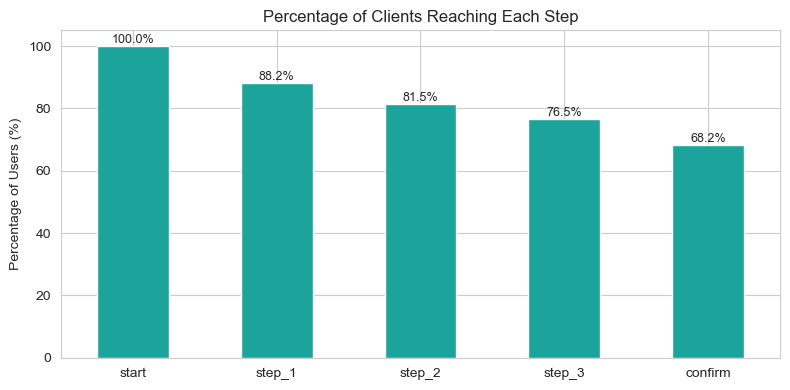

In [732]:
import matplotlib.pyplot as plt

step_order = ["start", "step_1", "step_2", "step_3", "confirm"]

# Count unique clients per step
clients_per_step = (
    web.groupby("process_step")["client_id"]
    .nunique()
    .reindex(step_order)
)

# Convert counts to percentage
clients_pct = (clients_per_step / clients_per_step.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(8, 4))

clients_pct.plot(
    kind="bar",
    ax=ax,
    color="#1ca39c",
    edgecolor="white"
)

ax.set_title("Percentage of Clients Reaching Each Step")
ax.set_ylabel("Percentage of Users (%)")
ax.set_xlabel("")
ax.set_xticklabels(step_order, rotation=0)
ax.set_ylim(0, 105)

# Add percentage labels on top
for i, v in enumerate(clients_pct.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()
plt.show()

In [733]:
merged = demo.merge(experiment, on="client_id", how="inner")

merged.columns = merged.columns.str.strip().str.lower().str.replace(" ", "_")

merged.head(3)

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,age_group,variation
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,55-64,Test
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0,55-64,Control
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0,18-34,Test


In [734]:
# To drop the unknown values:
merged["variation"].fillna("Unknown", inplace=True)
merged = merged[merged["variation"] != "Unknown"]

C:\Users\glint\AppData\Local\Temp\ipykernel_1564\3060071176.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged["variation"].fillna("Unknown", inplace=True)


In [735]:
grouped = merged.groupby("variation").agg({
    "clnt_age": ["mean", "median"],
    "num_accts": ["mean"],
    "clnt_tenure_yr": ["mean"],
    "gendr": lambda x: x.value_counts().to_dict()
})
grouped

clnt_age        num_accts clnt_tenure_yr  \
                mean median      mean           mean   
variation                                              
Control    47.498427   48.5  2.259925      12.087860   
Test       47.163922   47.5  2.249917      11.982901   

                                       gendr  
                                    <lambda>  
variation                                     
Control    {'U': 8014, 'M': 7970, 'F': 7542}  
Test       {'U': 9268, 'M': 8977, 'F': 8716}

In [736]:
counts = merged["variation"].value_counts()
print(counts)

variation
Test       26961
Control    23526
Name: count, dtype: int64


In [737]:
variance_percentage = (
    merged["variation"]
    .value_counts(normalize=True) * 100
).round(2)

variance_percentage

variation
Test       53.4
Control    46.6
Name: proportion, dtype: float64

In [738]:
merged_1 = merged.merge(web, on="client_id", how="inner")

merged_1.columns = merged_1.columns.str.strip().str.lower().str.replace(" ", "_")

merged_1.head(3)

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,age_group,variation,visitor_id,visit_id,process_step,date_time
0,836976,6.0,73.0,60.5,U,2.0,45105.3,6.0,9.0,55-64,Test,427070339_1413275162,228976764_46825473280_96584,confirm,2017-04-02 11:51:13
1,836976,6.0,73.0,60.5,U,2.0,45105.3,6.0,9.0,55-64,Test,427070339_1413275162,228976764_46825473280_96584,confirm,2017-04-02 11:47:50
2,836976,6.0,73.0,60.5,U,2.0,45105.3,6.0,9.0,55-64,Test,427070339_1413275162,228976764_46825473280_96584,confirm,2017-04-02 11:46:45


In [739]:
merged_1["variation"].value_counts()

variation
Test       177787
Control    143408
Name: count, dtype: int64

In [740]:
# Size of the Test group in %:
merged_1["variation"].value_counts()["Test"]
print((merged_1["variation"].value_counts()["Test"].sum() / len(merged_1) * 100).round(1))

55.4


In [741]:
merged_1["visit_id"].nunique()

69183

In [742]:
merged_1.groupby("variation")["visit_id"].nunique()

variation
Control    32181
Test       37122
Name: visit_id, dtype: int64

In [743]:
# Size of the Control group in %:
merged_1["variation"].value_counts()["Control"]
print((merged_1["variation"].value_counts()["Control"].sum() / len(merged_1) * 100).round(1))

44.6


In [744]:
# Check if each client_id belongs to only one "variation"
merged_1.groupby("client_id")["variation"].nunique().max()

# 1 means every client is in only one group (valid A/B test)

1

In [745]:
# Check if each visit belongs to only one "variation"
merged_1.groupby("visit_id")["variation"].nunique().max()

# 2 means that there are some visits that are related to each group

2

In [746]:
# Identify problematic visits
bad_visits = (
    merged_1.groupby("visit_id")["variation"]
    .nunique()
    .reset_index()
)

bad_visits = bad_visits[bad_visits["variation"] > 1]

print(len(bad_visits))

120


In [747]:
# Inspect the "bad visits"
merged_1[merged_1["visit_id"].isin(bad_visits)].sort_values("visit_id")

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,age_group,variation,visitor_id,visit_id,process_step,date_time


In [748]:
# Remove the bad sessions
bad_visits = merged_1.groupby("visit_id")["variation"].nunique()
bad_visits = bad_visits[bad_visits > 1].index

clean_df = merged_1[~merged_1["visit_id"].isin(bad_visits)].copy()

In [749]:
# Map steps to numbers
mapping = {
    "start": 1,
    "step_1": 2,
    "step_2": 3,
    "step_3": 4,
    "confirm": 5
}

clean_df["step_num"] = clean_df["process_step"].map(mapping)

# View result
clean_df.head(3)

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,age_group,variation,visitor_id,visit_id,process_step,date_time,step_num
0,836976,6.0,73.0,60.5,U,2.0,45105.3,6.0,9.0,55-64,Test,427070339_1413275162,228976764_46825473280_96584,confirm,2017-04-02 11:51:13,5
1,836976,6.0,73.0,60.5,U,2.0,45105.3,6.0,9.0,55-64,Test,427070339_1413275162,228976764_46825473280_96584,confirm,2017-04-02 11:47:50,5
2,836976,6.0,73.0,60.5,U,2.0,45105.3,6.0,9.0,55-64,Test,427070339_1413275162,228976764_46825473280_96584,confirm,2017-04-02 11:46:45,5


In [750]:
clean_df["date_time"] = pd.to_datetime(clean_df["date_time"])

clean_df = clean_df.sort_values(["client_id", "visit_id", "date_time"])

clean_df["duration"] = (
    clean_df.groupby(["client_id", "visit_id"])["date_time"]
    .shift(-1) - clean_df["date_time"]
)

clean_df["duration_min"] = clean_df["duration"].dt.total_seconds() / 60

clean_df = clean_df.dropna(subset=["duration_min"])

avg_duration = (
    clean_df
    .groupby(["variation", "process_step"])["duration_min"]
    .mean()
    .unstack()
)

avg_duration = avg_duration.reindex(columns=["start","step_1","step_2","step_3","confirm"])


In [751]:
df = clean_df.copy()
df["step_num"] = df["process_step"].map(mapping)

# Session-level funnel
session = (
    df.groupby(["variation", "client_id", "visit_id"])["step_num"]
    .max()
    .reset_index()
)

# Completion flag
session["completed"] = session["step_num"] == 4

# Summary
summary = session.groupby("variation").agg(
    started_sessions=("visit_id", "nunique"),
    completed_sessions=("completed", "sum")
).reset_index()

summary["completion_rate"] = (
    summary["completed_sessions"] / summary["started_sessions"] * 100
)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

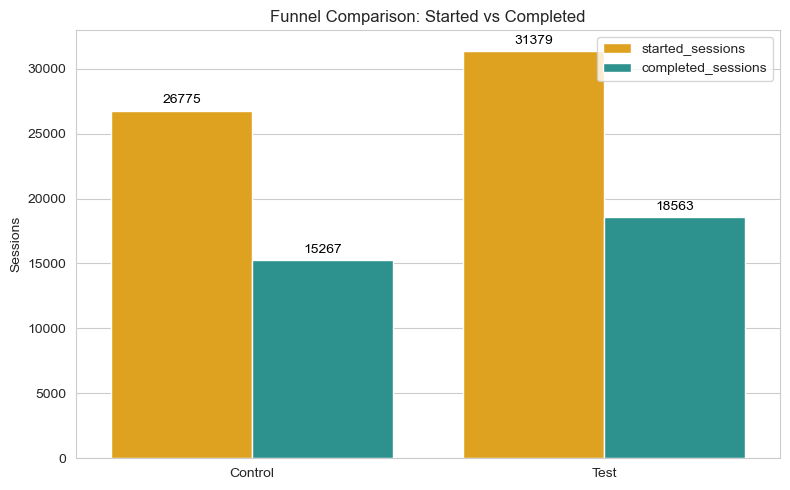

In [752]:
plot_df = summary.melt(
    id_vars="variation",
    value_vars=["started_sessions", "completed_sessions"],
    var_name="metric",
    value_name="count"
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=plot_df,
    x="variation",
    y="count",
    hue="metric",
    palette=["#ffad00", "#1ca39c"]
)

# Clean legend
ax.legend(title=None, loc="upper right")

# Add value labels (ONLY ONCE + skip zeros)
for bar in ax.patches:
    height = bar.get_height()

    if height == 0:
        continue

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + summary["started_sessions"].max() * 0.01,
        f"{int(height)}",
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

plt.title("Funnel Comparison: Started vs Completed")
plt.ylabel("Sessions")
plt.xlabel("")

plt.tight_layout()
plt.show()

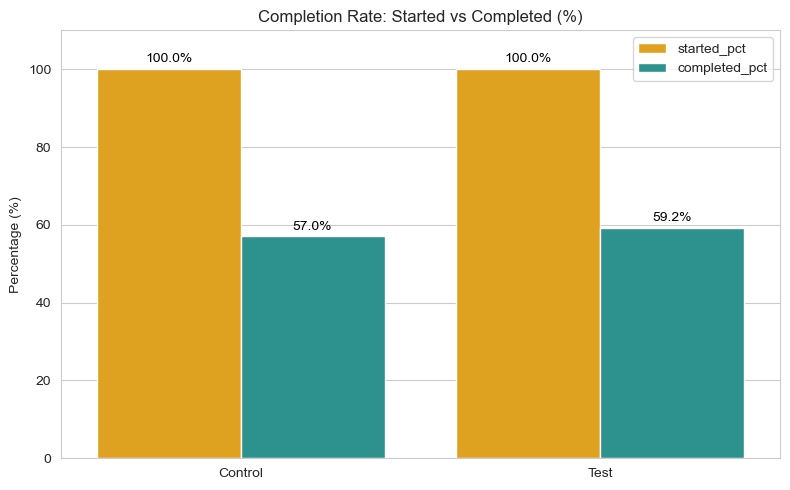

In [753]:
# Convert to percentages
summary_pct = summary.copy()

summary_pct["started_pct"] = 100  # baseline = 100%
summary_pct["completed_pct"] = (
    summary_pct["completed_sessions"] / summary_pct["started_sessions"] * 100
)

# Reshape for plotting
plot_df = summary_pct.melt(
    id_vars="variation",
    value_vars=["started_pct", "completed_pct"],
    var_name="metric",
    value_name="percent"
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=plot_df,
    x="variation",
    y="percent",
    hue="metric",
    palette=["#ffad00", "#1ca39c"]
)

# Clean legend
ax.legend(title=None, loc="upper right")

# Add percentage labels on top of bars
for bar in ax.patches:
    height = bar.get_height()

    # skip zeros just in case
    if height == 0:
        continue

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}%",
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

plt.title("Completion Rate: Started vs Completed (%)")
plt.ylabel("Percentage (%)")
plt.xlabel("")

plt.ylim(0, 110)  # gives space for labels above 100%

plt.tight_layout()
plt.show()

H₀ (null hypothesis): Completion rate (Control) = Completion rate (Test)

H₁ (alternative): Completion rates are different

This is a two-proportion z-test.

In [754]:
# Extract values from your summary
control = summary[summary["variation"] == "Control"]
test = summary[summary["variation"] == "Test"]

n_control = control["started_sessions"].values[0] # → selects that column (still a Series)
x_control = control["completed_sessions"].values[0] # .values → converts it into a NumPy array like [500]

n_test = test["started_sessions"].values[0] # [0] → grabs the first (and only) value → 500
x_test = test["completed_sessions"].values[0]

In [755]:
# Run a two-proportion z-test
from statsmodels.stats.proportion import proportions_ztest

count = [x_control, x_test]
nobs = [n_control, n_test]

z_stat, p_value = proportions_ztest(count, nobs)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: -5.209196199652002
P-value: 1.8966047591196096e-07


In [756]:
# Use a significance level (usually α = 0.05):
if p_value < 0.05:
    print("Reject H0 → Completion rates are significantly different")
else:
    print("Fail to reject H0 → No significant difference")

# Test group completion rate is LOWER than Control group
# A very strong statistical signal that something in the Test variant is hurting completion.

Reject H0 → Completion rates are significantly different


In [757]:
# Effect size
lift = (x_test/n_test) - (x_control/n_control)
print(lift)

# The Test group’s completion rate is +2.14 percentage points higher than Control.
# “The Test variant increased completion rate by ~2.1 percentage points. 
# This corresponds to ~2 additional conversions per 100 users.

0.02137790416845542


In [758]:
# Each row = one session, with the furthest step reached
session_max = (
    clean_df.groupby(["variation", "visit_id"])["step_num"]
    .max()
    .reset_index()
)

In [759]:
# To validate whether your A/B test result is not only statistically significant but also business-relevant, 
# you need to compare the relative uplift in completion rate against the 5% minimum threshold.
completion = (
    session_max.assign(completed=lambda df: df["step_num"] == 5)
    .groupby("variation")["completed"]
    .mean()
)

# Compute % uplift (Test vs Control)
control_rate = completion["Control"]
test_rate = completion["Test"]

uplift = (test_rate - control_rate) / control_rate
uplift

np.float64(0.7809316361004804)

In [760]:
# Compare the uplift to 5% threshold
if uplift >= 0.05:
    print("✅ Meets business threshold (≥ 5% uplift)")
else:
    print("❌ Does NOT meet business threshold (< 5% uplift)")

✅ Meets business threshold (≥ 5% uplift)


In [761]:
steps = [1, 2, 3, 4, 5]

funnel_counts = []

for var in session_max["variation"].unique():
    subset = session_max[session_max["variation"] == var]
    total_sessions = subset["visit_id"].nunique()
    
    for step in steps:
        reached = (subset["step_num"] >= step).sum()
        
        funnel_counts.append({
            "variation": var,
            "step_num": step,
            "sessions": reached,
            "total": total_sessions,
            "percentage": reached / total_sessions
        })

funnel_counts = pd.DataFrame(funnel_counts)

In [762]:
# Pivot table
funnel_pct = funnel_counts.pivot(
    index="step_num",
    columns="variation",
    values="percentage"
).sort_index()


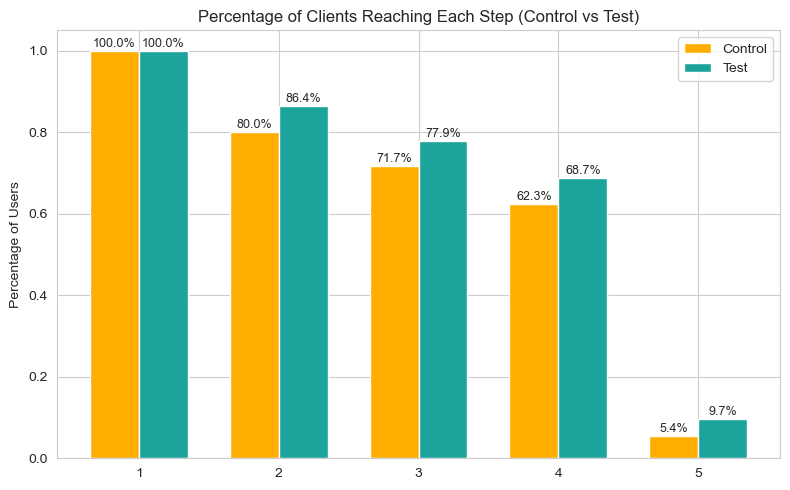

In [763]:
# Plot
# -----------------------
x = np.arange(len(steps))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

# Bars
ax.bar(x - width/2, funnel_pct["Control"], width, label="Control", color="#ffad00")
ax.bar(x + width/2, funnel_pct["Test"], width, label="Test", color="#1ca39c")

# Labels (Control)
for i, v in enumerate(funnel_pct["Control"]):
    ax.text(i - width/2, v + 0.01, f"{v:.1%}", ha="center", fontsize=9)

# Labels (Test)
for i, v in enumerate(funnel_pct["Test"]):
    ax.text(i + width/2, v + 0.01, f"{v:.1%}", ha="center", fontsize=9)

# Titles and axes
ax.set_title("Percentage of Clients Reaching Each Step (Control vs Test)")
ax.set_ylabel("Percentage of Users")
ax.set_xticks(x)
ax.set_xticklabels(steps)
ax.set_ylim(0, 1.05)

# Legend
ax.legend()

plt.tight_layout()
plt.show()

In [764]:
import pandas as pd

# Ensure datetime format
clean_df["date_time"] = pd.to_datetime(clean_df["date_time"])

# Sort values
df_sorted = clean_df.sort_values(["visit_id", "date_time"])

# Time difference between steps within each session
df_sorted["time_diff"] = df_sorted.groupby("visit_id")["date_time"].diff()

# Convert to seconds
df_sorted["time_diff_sec"] = df_sorted["time_diff"].dt.total_seconds()

# Remove first step of each session (NaN)
df_time = df_sorted.dropna(subset=["time_diff_sec"])

# Average time spent per step and variation
time_per_step = (
    df_time.groupby(["variation", "step_num"])["time_diff_sec"]
    .mean()
    .reset_index()
)

# Pivot for comparison
time_pivot = time_per_step.pivot(
    index="step_num",
    columns="variation",
    values="time_diff_sec"
)

time_pivot

variation,Control,Test
step_num,,
1,184.234581,162.832655
2,43.699251,37.197998
3,38.452285,47.731177
4,92.582716,95.888407
5,148.059159,193.639087


In [765]:
# Convert to minutes
time_pivot = time_pivot / 60

In [766]:
df_time.groupby(["variation", "step_num"])["time_diff_sec"].median()

variation  step_num
Control    1           50.0
           2           18.0
           3           20.0
           4           66.0
           5           61.0
Test       1           62.0
           2           11.0
           3           25.0
           4           66.0
           5           66.0
Name: time_diff_sec, dtype: float64

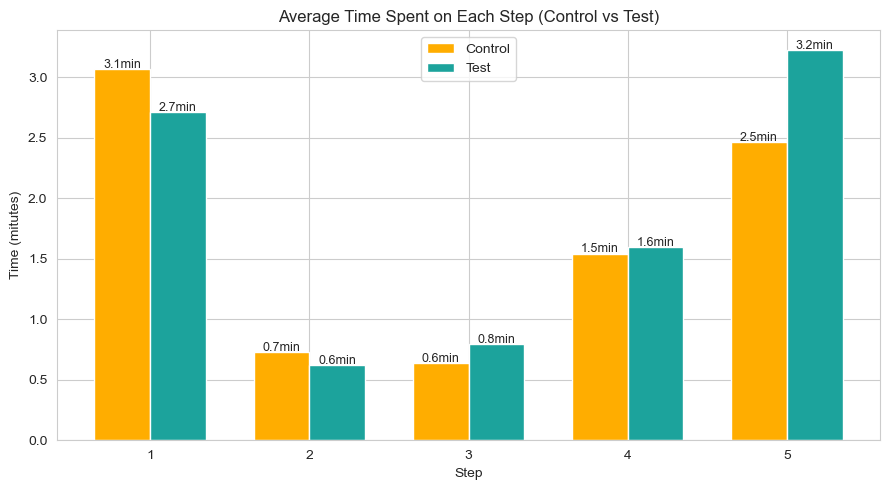

In [767]:
import numpy as np
import matplotlib.pyplot as plt

# Steps (x-axis)
steps = time_pivot.index
x = np.arange(len(steps))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

# Bars
ax.bar(x - width/2, time_pivot["Control"], width, label="Control", color="#ffad00")
ax.bar(x + width/2, time_pivot["Test"], width, label="Test", color="#1ca39c")

# Labels on bars
for i, v in enumerate(time_pivot["Control"]):
    ax.text(i - width/2, v + 0.01, f"{v:.1f}min", ha="center", fontsize=9)

for i, v in enumerate(time_pivot["Test"]):
    ax.text(i + width/2, v + 0.01, f"{v:.1f}min", ha="center", fontsize=9)

# Titles and axes
ax.set_title("Average Time Spent on Each Step (Control vs Test)")
ax.set_ylabel("Time (mitutes)")
ax.set_xlabel("Step")
ax.set_xticks(x)
ax.set_xticklabels(steps)
ax.legend()

plt.tight_layout()
plt.show()

In [768]:
# Check the number of accounts per client
clean_df.drop_duplicates("client_id")[["client_id", "num_accts"]]
clean_df.groupby("client_id")["num_accts"].first()

client_id
555        2.0
647        2.0
934        2.0
1028       3.0
1186       2.0
          ... 
9999150    3.0
9999400    2.0
9999626    2.0
9999729    3.0
9999832    2.0
Name: num_accts, Length: 46587, dtype: float64

In [769]:
df_clients = clean_df.drop_duplicates("client_id")

In [770]:
accounts_distribution = (
    df_clients.groupby("num_accts")["client_id"]
    .nunique()
    .reset_index(name="num_clients")
    .sort_values("num_accts")
)

accounts_distribution

,num_accts,num_clients
0,1.0,1
1,2.0,36590
2,3.0,8315
3,4.0,1467
4,5.0,188
5,6.0,21
6,7.0,5


In [771]:
clean_df["num_accts"].unique()

array([2., 3., 5., 4., 6., 7., 1.])

In [772]:
# Number of clients per accounts & variation
accounts_group = (
    df_clients.groupby(["variation", "num_accts"])["client_id"]
    .nunique()
    .reset_index(name="num_clients")
    .sort_values("num_accts")
)

accounts_group

,variation,num_accts,num_clients
6,Test,1.0,1
0,Control,2.0,16523
7,Test,2.0,20067
1,Control,3.0,3886
8,Test,3.0,4429
2,Control,4.0,682
9,Test,4.0,785
3,Control,5.0,101
10,Test,5.0,87
4,Control,6.0,8


In [773]:
# Check clients with > 2 accounts
filtered = df_clients[df_clients["num_accts"] > 2]

In [774]:
general = df_clients[df_clients["num_accts"] == 2]
result = (
    general.groupby("variation")["client_id"]
    .nunique()
    .reset_index(name="num_clients")
)
result

# Total 36,590 clients with 2 accounts in both groups

,variation,num_clients
0,Control,16523
1,Test,20067


In [775]:
# Count by variation
result = (
    filtered.groupby("variation")["client_id"]
    .nunique()
    .reset_index(name="num_clients")
)

result

# 🏦 It seems that the dataset is built with a rule like “multi-account users only”
# 🧾 Or, the business model assumes account linking (e.g. basic + savings)

,variation,num_clients
0,Control,4679
1,Test,5317


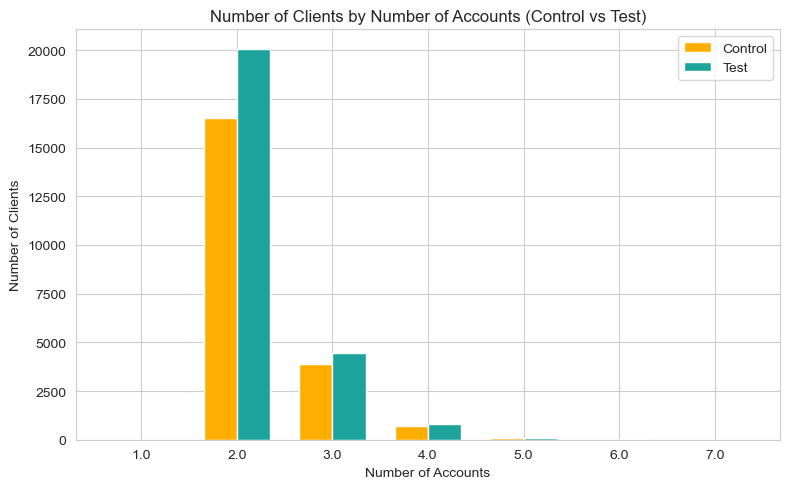

In [776]:
# Pivot the data
accounts_pivot = accounts_group.pivot(
    index="num_accts",
    columns="variation",
    values="num_clients"
).fillna(0)

# X positions
x = np.arange(len(accounts_pivot.index))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

# Bars
ax.bar(x - width/2, accounts_pivot["Control"], width, label="Control", color="#ffad00")
ax.bar(x + width/2, accounts_pivot["Test"], width, label="Test", color="#1ca39c")

# Labels
ax.set_title("Number of Clients by Number of Accounts (Control vs Test)")
ax.set_xlabel("Number of Accounts")
ax.set_ylabel("Number of Clients")

ax.set_xticks(x)
ax.set_xticklabels(accounts_pivot.index)

ax.legend()

plt.tight_layout()
plt.show()

In [777]:
# Keep 1 row per client: exclude duplicates
df_clients = clean_df.sort_values("date_time").drop_duplicates(subset="client_id", keep="last")

In [778]:
# Aggregate total calls
calls = (
    df_clients.groupby(["variation", "age_group"])["calls_6_mnth"]
    .sum()
    .reset_index()
)
calls

C:\Users\glint\AppData\Local\Temp\ipykernel_1564\132119406.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clients.groupby(["variation", "age_group"])["calls_6_mnth"]


,variation,age_group,calls_6_mnth
0,Control,18-34,18838.0
1,Control,35-44,10181.0
2,Control,45-54,12300.0
3,Control,55-64,14979.0
4,Control,65+,10516.0
5,Test,18-34,22210.0
6,Test,35-44,11919.0
7,Test,45-54,14758.0
8,Test,55-64,17195.0
9,Test,65+,11792.0


In [779]:
# Convert to % with each variation
calls["percentage"] = (
    calls.groupby("variation")["calls_6_mnth"]
    .transform(lambda x: x / x.sum() * 100)
)

In [780]:
# Pivot table
calls_pivot = calls.pivot(
    index="age_group",
    columns="variation",
    values="percentage"
).round()

calls_pivot

variation,Control,Test
age_group,,
18-34,28.0,29.0
35-44,15.0,15.0
45-54,18.0,19.0
55-64,22.0,22.0
65+,16.0,15.0
